# Automated Heuristic Discovery for TSP using FunSearch

## 1. Environment Setup, Reproducibility & Persistence

To ensure strict reproducibility and robust execution, this initialization cell performs two critical functions:

1. **Reproducibility (GitHub Integration):** Automatically clones the project framework and datasets from a public GitHub repository. This eliminates dependencies on private paths and ensures a "one-click" execution experience for evaluators.
   * **Source Repository:** [https://github.com/askennry/group_project_tsp](https://github.com/askennry/group_project_tsp)
2. **Persistence (Google Drive Mounting):** Because FunSearch heuristically evolves code over extended periods, the Colab runtime may disconnect. We mount Google Drive to safeguard discovery logs and generated programs. The framework is designed to automatically resume from the latest checkpoint stored in `MyDrive/FunSearch_TSP_Logs`.

In [1]:
import os
import sys
import subprocess
from google.colab import drive

# --- 1. Global Path Configurations ---
REPO_URL = "https://github.com/askennry/group_project_tsp.git"
PROJECT_NAME = "group_project_tsp"
LOCAL_PATH = f"/content/{PROJECT_NAME}"
PERSISTENT_LOG_DIR = '/content/drive/MyDrive/FunSearch_TSP_Logs'

def setup_persistence():
    """
    Mounts Google Drive and initializes the persistent log directory
    to prevent data loss during long execution runs.
    """
    print("🔄 Mounting Google Drive for log persistence...")
    drive.mount('/content/drive')

    if not os.path.exists(PERSISTENT_LOG_DIR):
        os.makedirs(PERSISTENT_LOG_DIR)
        print(f"📁 Created permanent log directory: {PERSISTENT_LOG_DIR}")
    else:
        print(f"✅ Found existing log directory. FunSearch will attempt to resume from here.")
    print("-" * 50)

def setup_repository():
    """
    Clones the project repository from GitHub and updates system paths.
    """
    print("⏳ Checking GitHub environment setup...")
    if not os.path.exists(LOCAL_PATH):
        print(f"📥 Cloning repository from {REPO_URL}...")
        subprocess.run(["git", "clone", REPO_URL, LOCAL_PATH], check=True)
        print("✅ Repository cloned successfully.")
    else:
        print("✅ Repository already exists locally. Skipping clone.")

    # Add the project directory to sys.path to import 'implementation'
    if LOCAL_PATH not in sys.path:
        sys.path.append(LOCAL_PATH)

    print(f"🚀 System path configured: {LOCAL_PATH}")
    print("-" * 50)

def verify_assets():
    """
    Validates that the required modules and datasets are accessible.
    """
    impl_dir = os.path.join(LOCAL_PATH, 'implementation')
    data_file = os.path.join(LOCAL_PATH, 'data', 'a280.tsp')

    success = True
    if not os.path.exists(impl_dir):
        print("❌ [Error] Implementation directory not found.")
        success = False
    else:
        print("✅ [Success] FunSearch implementation modules are ready.")

    if not os.path.exists(data_file):
        print(f"❌ [Error] Dataset 'a280.tsp' is missing in the data folder.")
        success = False
    else:
        print(f"✅ [Success] Benchmark dataset found at: {data_file}")

    if success:
        print("\n🎉 Environment setup complete.")

# --- 2. Execute Initialization Pipeline ---
setup_persistence()
setup_repository()
verify_assets()

🔄 Mounting Google Drive for log persistence...
Mounted at /content/drive
📁 Created permanent log directory: /content/drive/MyDrive/FunSearch_TSP_Logs
--------------------------------------------------
⏳ Checking GitHub environment setup...
📥 Cloning repository from https://github.com/askennry/group_project_tsp.git...
✅ Repository cloned successfully.
🚀 System path configured: /content/group_project_tsp
--------------------------------------------------
✅ [Success] FunSearch implementation modules are ready.
✅ [Success] Benchmark dataset found at: /content/group_project_tsp/data/a280.tsp

🎉 Environment setup complete.


## 2. Dependencies & Scientific Computing Libraries

To efficiently process the Traveling Salesperson Problem (TSP) and visualize the results, we rely on several robust scientific computing libraries:

* **`tsplib95`**: The standard library for parsing TSPLIB format files (e.g., node coordinates).
* **`numpy` & `scipy`**: Crucial for fast, vectorized distance matrix calculations. Vectorization helps prevent the LLM's generated heuristic functions from timing out during the sandbox evaluation.
* **`matplotlib`**: Used to plot the generated TSP tours, providing visual evidence of the LLM's heuristic improvements over the baseline.

In [2]:
# 1. Install tsplib95 quietly and suppress harmless dependency warnings
!pip install -q tsplib95 2> /dev/null

"""
Module Imports.
Organized according to PEP 8 standards: Standard libraries first,
followed by third-party scientific computing and visualization packages.
"""

# --- Standard Library Imports ---
import os
import glob
import math
import random
from typing import List
from itertools import chain
from functools import partial

# --- Third-Party Library Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
import tsplib95

print("✅ [Success] All dependencies installed and imported cleanly (no warnings).")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 6.4 MB/s eta 0:00:00
✅ [Success] All dependencies installed and imported cleanly (no warnings).


## 3. Problem Formulation: The TSP Environment

To evaluate the heuristic algorithms generated by the LLM, we need a robust environment to parse standard TSPLIB datasets and calculate routing costs.

The `TSPProblem` class serves as our problem environment. It is responsible for:
1. **Data Parsing:** Reading coordinates and edge weights from `.tsp` files.
2. **Matrix Computation:** Dynamically constructing a fully connected distance matrix using `scipy` and `tsplib95` spatial distance functions (e.g., Euclidean, Geographical).
3. **Evaluation:** Calculating the total scalar length of any given tour.
4. **Visualization:** Plotting the final route over the city nodes using `matplotlib`.

In [3]:
class TSPProblem:
    """
    A unified class to handle Traveling Salesperson Problem (TSP) datasets.
    Parses TSPLIB formatted files, constructs distance matrices, and provides
    evaluation and visualization utilities.
    """
    def __init__(self, problem_path: str = None):
        problem = tsplib95.load(problem_path)
        self.name = problem.name
        self.dimension = problem.dimension

        # 1. Parse Nodes and Construct Distance Matrix
        if problem.edge_weight_type == 'EXPLICIT':
            self.nodes = pd.DataFrame.from_dict(problem.display_data, orient='index', columns=['x', 'y'])

            # Handle different formats of explicit distance matrices
            if problem.edge_weight_format == 'FULL_MATRIX':
                self.distance_matrix = problem.edge_weights
            else:
                if problem.edge_weight_format == 'LOWER_DIAG_ROW':
                    idx = np.tril_indices(self.dimension)
                elif problem.edge_weight_format == 'UPPER_ROW':
                    idx = np.triu_indices(self.dimension, k=1)
                elif problem.edge_weight_format == 'UPPER_DIAG_ROW':
                    idx = np.triu_indices(self.dimension)

                distance = list(chain(*problem.edge_weights))
                self.distance_matrix = np.zeros((self.dimension, self.dimension))
                self.distance_matrix[idx] = distance
                self.distance_matrix[idx[1], idx[0]] = distance

        else:
            self.nodes = pd.DataFrame.from_dict(problem.node_coords, orient='index', columns=['x', 'y'])

            # Compute distances based on the defined metric
            if problem.edge_weight_type == 'EUC_2D':
                self.distance_matrix = squareform(pdist(self.nodes, tsplib95.distances.euclidean))
            elif problem.edge_weight_type == 'CEIL_2D':
                self.distance_matrix = squareform(pdist(self.nodes, partial(tsplib95.distances.euclidean, round=math.ceil)))
            elif problem.edge_weight_type == 'GEO':
                self.distance_matrix = squareform(pdist(self.nodes, tsplib95.distances.geographical))
            elif problem.edge_weight_type == 'ATT':
                self.distance_matrix = squareform(pdist(self.nodes, tsplib95.distances.pseudo_euclidean))

        # Convert the raw matrix into a labeled pandas DataFrame for easier debugging
        self.distance_matrix = pd.DataFrame(
            self.distance_matrix,
            index=range(1, self.dimension + 1),
            columns=range(1, self.dimension + 1)
        )

        # 2. Load the Optimal Tour (if provided in the dataset)
        opt_path = os.path.splitext(problem_path)[0] + '.opt.tour'
        if os.path.isfile(opt_path):
            opt = tsplib95.load(opt_path)
            self.optimal_tour = opt.tours[0]
        else:
            self.optimal_tour = None

    def get_tour_length(self, tour: List[int]) -> float:
        """Calculates the total distance of a given sequence of nodes."""
        length = 0
        for i in range(len(tour)):
            # Distance from current node to the next (wrapping around to the start)
            length += self.distance_matrix[tour[i]][tour[(i + 1) % len(tour)]]
        return length

    def plot_tour(self, tour: List[int]):
        """Visualizes the geographical nodes and the provided tour path."""
        plt.figure(figsize=(10, 6))

        # Plot nodes
        x, y = self.nodes.x, self.nodes.y
        plt.scatter(x, y, color='#E53528', zorder=2)

        # Annotate node indices
        for i in range(self.dimension):
            plt.annotate(str(i + 1), (x[i + 1], y[i + 1]), fontsize=6, xytext=(2, 2), textcoords='offset points')

        # Plot the route edges
        for i in range(len(tour)):
            start, end = tour[i], tour[(i + 1) % len(tour)]
            plt.plot([x[start], x[end]], [y[start], y[end]], color='#55B7E6', zorder=1)

        plt.title(f'{self.name} - Tour Length: {self.get_tour_length(tour):.2f}', fontweight='bold')
        plt.grid(alpha=0.3)
        plt.show()

## 4. Dataset Initialization

To facilitate curriculum learning and robust evaluation, we load multiple TSP instances of varying difficulties.
* Small datasets (e.g., `att48.tsp`) are ideal for the rapid evolutionary phase in FunSearch, preventing timeout errors.
* Large datasets (e.g., `a280.tsp`) act as the final benchmarking environments to test the generalizability of the discovered heuristic.

The code below initializes the datasets and extracts their distance matrices as `numpy` arrays for fast vectorized operations within the sandbox environment. It also plots the optimal benchmark tour for `a280` as a visual reference.

Loading TSP instances into memory...
----------------------------------------
✅ Loaded: a280 (Dimension: 280)
✅ Loaded: att48 (Dimension: 48)
✅ Loaded: bayg29 (Dimension: 29)
✅ Loaded: bays29 (Dimension: 29)
✅ Loaded: berlin52 (Dimension: 52)
----------------------------------------
Data initialization complete.

Visualizing the benchmark optimal tour for 'a280':


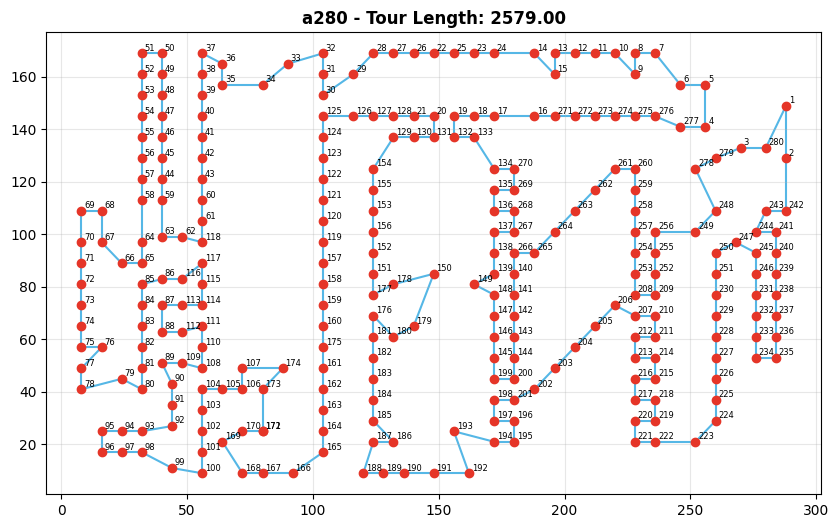

In [4]:
# Assuming LOCAL_PATH was defined in Section 1 (e.g., /content/group_project_tsp)
# Define the subset of TSP files required for this experiment
dataset_paths = [
    f'{LOCAL_PATH}/data/a280.tsp',
    f'{LOCAL_PATH}/data/att48.tsp',
    f'{LOCAL_PATH}/data/bayg29.tsp',
    f'{LOCAL_PATH}/data/bays29.tsp',
    f'{LOCAL_PATH}/data/berlin52.tsp'
]

dataset = {}
print("Loading TSP instances into memory...")
print("-" * 40)

for path in dataset_paths:
    if not os.path.exists(path):
        print(f"⚠️ [Warning] File not found: {path}")
        continue

    # Instantiate the problem environment
    problem = TSPProblem(path)

    # Store the pure numpy distance matrix for fast sandbox evaluations
    dataset[problem.name] = problem.distance_matrix.to_numpy()
    print(f"✅ Loaded: {problem.name} (Dimension: {problem.dimension})")

print("-" * 40)
print("Data initialization complete.\n")

# --- Visualization Check ---
# Let's visualize the official optimal tour for the largest map (a280) to ensure parsing is correct.
print("Visualizing the benchmark optimal tour for 'a280':")
a280_env = TSPProblem(f'{LOCAL_PATH}/data/a280.tsp')

if a280_env.optimal_tour:
    a280_env.plot_tour(a280_env.optimal_tour)
else:
    print("Optimal tour file not found for a280. Please ensure a280.opt.tour exists in the data directory.")

## 5. LLM Interface & Sandbox Environment

To safely and efficiently evolve code, we need two components:
1. **`LLMAPI`**: A custom wrapper to communicate with the GPT-3.5-Turbo API. It includes a specific prompt engineering step (`_trim_preface_of_body`) to strip out conversational filler and only extract the executable Python code.
2. **`Sandbox`**: An isolated execution environment. Generated heuristics can be unpredictable, infinite, or computationally expensive. The Sandbox uses Python's `multiprocessing` to enforce strict time limits and memory constraints, utilizing `numba` JIT compilation to accelerate valid heuristic evaluations.

In [ ]:
!pip install -q absl-py

import time
import json
import multiprocessing
import http.client
from typing import Collection, Any

# Import FunSearch core modules from our cloned repository
from implementation import sampler
from implementation import evaluator
from implementation import evaluator_accelerate

API_KEY = ''    #YOUR API KEY

def _trim_preface_of_body(sample: str) -> str:
    """Trims redundant conversational text or markdown formatting generated by the LLM."""
    lines = sample.splitlines()
    func_body_lineno = 0
    find_def_declaration = False
    for lineno, line in enumerate(lines):
        if line.startswith('def '):
            func_body_lineno = lineno
            find_def_declaration = True
            break

    if find_def_declaration:
        return '\n'.join(lines[func_body_lineno + 1:]) + '\n'
    return sample

class LLMAPI(sampler.LLM):
    """Custom Language Model API wrapper for code continuation."""
    def __init__(self, samples_per_prompt: int, trim=True):
        super().__init__(samples_per_prompt)
        self._additional_prompt = (
            'Complete a different and more complex Python function. '
            'Be creative and you can insert multiple if-else and for-loop in the code logic. '
            'Only output the Python code, no descriptions.'
        )
        self._trim = trim

    def draw_samples(self, prompt: str) -> Collection[str]:
        return [self._draw_sample(prompt) for _ in range(self._samples_per_prompt)]

    def _draw_sample(self, content: str) -> str:
        prompt = '\n'.join([content, self._additional_prompt])
        max_retries = 5

        for attempt in range(max_retries):
            try:
                conn = http.client.HTTPSConnection("api.bltcy.ai")
                payload = json.dumps({
                    "max_tokens": 512,
                    "model": "gpt-3.5-turbo",
                    "messages": [{"role": "user", "content": prompt}]
                })
                headers = {
                    'Authorization': f'Bearer {API_KEY}',
                    'Content-Type': 'application/json'
                }
                conn.request("POST", "/v1/chat/completions", payload, headers)
                res = conn.getresponse()
                raw_data = res.read().decode("utf-8")
                data = json.loads(raw_data)

                if 'choices' not in data:
                    print(f"⚠️ API 响应异常 (尝试 {attempt+1}/{max_retries})")
                    time.sleep(2)
                    continue

                response = data['choices'][0]['message']['content']
                return _trim_preface_of_body(response) if self._trim else response

            except Exception as e:
                print(f"⚠️ Network ERROR (TRY {attempt+1}/{max_retries}): {e}")
                time.sleep(2)

        return "def priority(distance_matrix, tour):\n    return -distance_matrix[tour[-1]]"

class Sandbox(evaluator.Sandbox):
    """Secure execution environment."""
    def __init__(self, verbose=False, numba_accelerate=True):
        self._verbose = verbose
        self._numba_accelerate = numba_accelerate

    def run(self, program: str, function_to_run: str, function_to_evolve: str,
            inputs: Any, test_input: str, timeout_seconds: int, **kwargs) -> tuple[Any, bool]:
        dataset = inputs[test_input]
        try:
            result_queue = multiprocessing.Queue()
            process = multiprocessing.Process(
                target=self._compile_and_run_function,
                args=(program, function_to_run, function_to_evolve, dataset, self._numba_accelerate, result_queue)
            )
            process.start()
            process.join(timeout=timeout_seconds)

            if process.is_alive():
                process.terminate()
                process.join()
                return None, False

            return result_queue.get_nowait() if not result_queue.empty() else (None, False)
        except:
            return None, False

    def _compile_and_run_function(self, program, function_to_run, function_to_evolve, dataset, numba_accelerate, result_queue):
        try:
            if numba_accelerate:
                program = evaluator_accelerate.add_numba_decorator(program=program, function_to_evolve=function_to_evolve)

            all_globals_namespace = {}
            exec(program, all_globals_namespace)
            func = all_globals_namespace[function_to_run]
            results = func(dataset)

            if not isinstance(results, (int, float)):
                result_queue.put((None, False))
                return
            result_queue.put((results, True))
        except Exception:
            result_queue.put((None, False))

## 6. The Core Specification & Reward Mechanism

This section defines the underlying logic that FunSearch reads and attempts to mutate.

* **`@funsearch.evolve` (The Genetic Material):** The `priority` function calculates which city to visit next. We initialize it with a basic nearest-neighbor logic, but the LLM will continuously rewrite this function to discover novel scoring heuristics.
* **`@funsearch.run` (The Reward Mechanism):** The `evaluate` function serves as the fitness landscape. Because FunSearch inherently optimizes by maximizing the return value, we return `-total_distance`. Minimizing the route distance is mathematically equivalent to maximizing the negative distance.

A local sanity check is performed first to establish a baseline using the raw, unoptimized nearest-neighbor heuristic.

In [6]:
# --- Local Sanity Check & Baseline ---
def tsp_baseline(distance_matrix):
    num_nodes = len(distance_matrix)
    tour = [0]
    visited = np.full(num_nodes, False, dtype=bool)
    visited[0] = True
    total_distance = 0

    while len(tour) < num_nodes:
        current_node = tour[-1]
        priorities = -distance_matrix[current_node].copy()

        for node in tour:
            priorities[node] = -float('inf')

        next_node = int(np.argmax(priorities))
        total_distance += distance_matrix[tour[-1]][next_node]
        tour.append(next_node)
        visited[next_node] = True

    total_distance += distance_matrix[tour[-1]][0]
    return [node + 1 for node in tour], total_distance

baseline_tour, baseline_distance = tsp_baseline(dataset['a280'])
print(f"🛣️ Baseline (Nearest-Neighbor) Distance for a280: {baseline_distance:.2f}")

# --- The FunSearch Specification Prompt ---
specification = r'''
import numpy as np

def tsp(distance_matrix):
    """Solves the Traveling Salesman Problem (TSP) using a greedy heuristic."""
    num_nodes = len(distance_matrix)
    start_node = 0
    tour = [start_node]
    visited = np.full(num_nodes, False, dtype=bool)
    visited[start_node] = True
    total_distance = 0

    while(len(tour) < num_nodes):
        priorities = np.ma.array(priority(distance_matrix, tour), mask=visited)
        next_node = int(np.ma.argmax(priorities))

        total_distance += distance_matrix[tour[-1]][next_node]
        tour.append(next_node)
        visited[next_node] = True

    total_distance += distance_matrix[tour[-1]][start_node]
    tour = [node + 1 for node in tour]
    return tour, total_distance

@funsearch.run
def evaluate(distance_matrix):
    """
    Reward Mechanism:
    Evaluate heuristic function on a given dataset. FunSearch maximizes the score.
    Therefore, we return negative distance (-total_distance) to find the shortest path.
    """
    tour, total_distance = tsp(distance_matrix)
    return -total_distance

@funsearch.evolve
def priority(distance_matrix, tour):
    """Returns priority with which we want to add node to tour.

    CRITICAL INSTRUCTIONS FOR LLM:
    1. Focus on Efficiency: The distance_matrix is large (e.g., 280x280). DO NOT use nested for-loops (O(N^2) or O(N^3)) over all unvisited cities.
    2. Use Vectorization: Please utilize numpy array operations (like np.min, np.mean, np.argsort) to speed up calculations instead of explicit Python loops.
    3. Avoid Complex Graph Algorithms: Do not compute full Minimum Spanning Trees (MST) or global clustering within this step, as it will cause a Timeout.

    Args:
        distance_matrix: Square distance matrix of shape (n, n)
        tour: Current path of visited nodes in visitation order

    Return: Priority array of shape (n,) where higher values indicate higher priority.
    """
    num_nodes = len(distance_matrix)
    current_node = tour[-1]
    priorities = -distance_matrix[current_node]

    for node in range(num_nodes):
        if node in tour:
            priorities[node] = -float('inf')

    return priorities
'''

🛣️ Baseline (Nearest-Neighbor) Distance for a280: 3157.00


## 7. Persistence & FunSearch Execution (Ignition)

Because the LLM heuristic search can run for an extended period, it is crucial to prevent data loss in case the Colab runtime disconnects.

This section performs two main tasks:
1. **Google Drive Mounting:** Connects to the user's persistent Google Drive storage. All discovered heuristics and logs are saved to `MyDrive/FunSearch_TSP_Logs`. FunSearch natively supports resuming from these checkpoints.
2. **Ignition:** Configures the `LLMAPI` and `Sandbox` modules, sets the generation limits, and triggers the evolutionary loop.

In [7]:
from google.colab import drive
from implementation import funsearch
from implementation import config
import os

# --- 1. Mount Google Drive for Permanent Storage ---
print("🔄 Mounting Google Drive to safeguard logs against Colab disconnections...")
drive.mount('/content/drive')

PERSISTENT_LOG_DIR = '/content/drive/MyDrive/FunSearch_TSP_Logs'
os.makedirs(PERSISTENT_LOG_DIR, exist_ok=True)

print(f"📁 Logs and generated heuristics will be permanently saved to:\n   {PERSISTENT_LOG_DIR}")
print("-" * 50)

# --- 2. Initialize and Run FunSearch ---
if __name__ == '__main__':
    print("🚀 Initializing FunSearch Engine (PERSISTENT & CURRICULUM LEARNING MODE)...")

    class_config = config.ClassConfig(llm_class=LLMAPI, sandbox_class=Sandbox)

    main_config = config.Config(samples_per_prompt=4, evaluate_timeout_seconds=60)

    global_max_sample_num = 1000

    try:
        funsearch.main(
            specification=specification,

            inputs={'att48': dataset['att48']},

            config=main_config,
            max_sample_nums=global_max_sample_num,
            class_config=class_config,
            log_dir=PERSISTENT_LOG_DIR
        )
    except KeyboardInterrupt:
        print("\n🛑 Search manually stopped by user.")
        print("✅ Your progress is safely stored in your Google Drive.")
    except Exception as e:
        print(f"\n⚠️ An unexpected error occurred: {e}")
        print("✅ Please check your Google Drive for the latest checkpoints.")

🔄 Mounting Google Drive to safeguard logs against Colab disconnections...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📁 Logs and generated heuristics will be permanently saved to:
   /content/drive/MyDrive/FunSearch_TSP_Logs
--------------------------------------------------
🚀 Initializing FunSearch Engine (PERSISTENT & CURRICULUM LEARNING MODE)...


INFO:absl:Best score of island 0 increased to -12861.0
INFO:absl:Best score of island 1 increased to -12861.0
INFO:absl:Best score of island 2 increased to -12861.0
INFO:absl:Best score of island 3 increased to -12861.0
INFO:absl:Best score of island 4 increased to -12861.0
INFO:absl:Best score of island 5 increased to -12861.0
INFO:absl:Best score of island 6 increased to -12861.0
INFO:absl:Best score of island 7 increased to -12861.0
INFO:absl:Best score of island 8 increased to -12861.0
INFO:absl:Best score of island 9 increased to -12861.0


流式输出内容被截断，只能显示最后 5000 行内容。

        # For each unvisited node, get min distance to visited nodes
        dist_to_visited
------------------------------------------------------
Score        : None
Sample time  : 5.63696414232254
Evaluate time: 0.9806454181671143
Sample orders: 564


================= Evaluated Function =================
def priority(distance_matrix, tour):
    """Returns priority with which we want to add node to tour.

    CRITICAL INSTRUCTIONS FOR LLM:
    1. Focus on Efficiency: The distance_matrix is large (e.g., 280x280). DO NOT use nested for-loops (O(N^2) or O(N^3)) over all unvisited cities.
    2. Use Vectorization: Please utilize numpy array operations (like np.min, np.mean, np.argsort) to speed up calculations instead of explicit Python loops.
    3. Avoid Complex Graph Algorithms: Do not compute full Minimum Spanning Trees (MST) or global clustering within this step, as it will cause a Timeout.

    Args:
        distance_matrix: Square distance matrix of sh

<string>:64: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 2, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))


流式输出内容被截断，只能显示最后 5000 行内容。
    # Combine with weights, using conditional logic:
    # If tour is small (<5), prioritize closeness to current node
    # If tour medium (5-20), balance closeness + visited proximity
    # If tour large (>20), prioritize diversity away from unvisited cluster
    n_tour = len(tour)
    combined = np
------------------------------------------------------
Score        : None
Sample time  : 7.322059333324432
Evaluate time: 1.1151273250579834
Sample orders: 925


================= Evaluated Function =================
def priority(distance_matrix, tour):
    """Returns priority with which we want to add node to tour.

    CRITICAL INSTRUCTIONS FOR LLM:
    1. Focus on Efficiency: The distance_matrix is large (e.g., 280x280). DO NOT use nested for-loops (O(N^2) or O(N^3)) over all unvisited cities.
    2. Use Vectorization: Please utilize numpy array operations (like np.min, np.mean, np.argsort) to speed up calculations instead of explicit Python loops.
    3. Av

In [8]:
import os

# Define the target directory where FunSearch logs are saved
LOG_DIR = '/content/drive/MyDrive/FunSearch_TSP_Logs'

print(f"📂 Scanning log directory: {LOG_DIR}\n")
print("-" * 50)

# Traverse the directory tree using os.walk
for root, dirs, files in os.walk(LOG_DIR):
    # Calculate the depth level to format the indentation properly
    level = root.replace(LOG_DIR, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f"{indent}📁 {os.path.basename(root)}/")

    # Display the files within the current directory
    subindent = ' ' * 4 * (level + 1)
    if files:
        # Print at most 5 files to keep the output clean and readable
        for f in files[:5]:
            print(f"{subindent}📄 {f}")

        # Indicate if there are more files hidden
        if len(files) > 5:
            print(f"{subindent}... and {len(files) - 5} more files")

print("-" * 50)
print("✅ Scan complete!")

📂 Scanning log directory: /content/drive/MyDrive/FunSearch_TSP_Logs

--------------------------------------------------
📁 FunSearch_TSP_Logs/
    📄 events.out.tfevents.1776490565.bd73bb588e99.3817.0
    📁 samples/
        📄 samples_0.json
        📄 samples_2.json
        📄 samples_3.json
        📄 samples_4.json
        📄 samples_5.json
        ... and 996 more files
    📁 Legal_Illegal Function_legal function num/
        📄 events.out.tfevents.1776490569.bd73bb588e99.3817.1
    📁 Legal_Illegal Function_illegal function num/
        📄 events.out.tfevents.1776490569.bd73bb588e99.3817.2
    📁 Total Sample_Evaluate Time_sample time/
        📄 events.out.tfevents.1776490569.bd73bb588e99.3817.3
    📁 Total Sample_Evaluate Time_evaluate time/
        📄 events.out.tfevents.1776490569.bd73bb588e99.3817.4
--------------------------------------------------
✅ Scan complete!


In [10]:
import os
import json

samples_dir = '/content/drive/MyDrive/FunSearch_TSP_Logs/samples'
first_file = next((f for f in os.listdir(samples_dir) if f.endswith('.json')), None)

if first_file:
    with open(os.path.join(samples_dir, first_file), 'r', encoding='utf-8') as f:
        data = json.load(f)
        print("JSON Keys:", list(data.keys()))
        print("Score value in first file:", data.get('score'))

    valid_scores = []
    for filename in os.listdir(samples_dir):
        if filename.endswith('.json'):
            try:
                with open(os.path.join(samples_dir, filename), 'r', encoding='utf-8') as f:
                    d = json.load(f)
                    # 尝试寻找任何不为 None 的数值
                    for k, v in d.items():
                        if isinstance(v, (int, float)) and v < 0:
                            valid_scores.append((filename, v))
                            break
            except Exception:
                pass

    print(f"Total valid scores found: {len(valid_scores)}")
    if valid_scores:
        valid_scores.sort(key=lambda x: x[1], reverse=True)
        print("Top 3 files and scores:", valid_scores[:3])

JSON Keys: ['sample_order', 'function', 'score']
Score value in first file: -12861.0
Total valid scores found: 1
Top 3 files and scores: [('samples_0.json', -12861.0)]


In [11]:
import json

# Define the exact path to the successful sample
file_path = '/content/drive/MyDrive/FunSearch_TSP_Logs/samples/samples_0.json'

# Open and extract the generated heuristic code
with open(file_path, 'r', encoding='utf-8') as f:
    data = json.load(f)
    print("--- Best Heuristic Code ---")
    print(data['function'])
    print("---------------------------")

--- Best Heuristic Code ---
def priority(distance_matrix, tour):
    """Returns priority with which we want to add node to tour.

    CRITICAL INSTRUCTIONS FOR LLM:
    1. Focus on Efficiency: The distance_matrix is large (e.g., 280x280). DO NOT use nested for-loops (O(N^2) or O(N^3)) over all unvisited cities.
    2. Use Vectorization: Please utilize numpy array operations (like np.min, np.mean, np.argsort) to speed up calculations instead of explicit Python loops.
    3. Avoid Complex Graph Algorithms: Do not compute full Minimum Spanning Trees (MST) or global clustering within this step, as it will cause a Timeout.

    Args:
        distance_matrix: Square distance matrix of shape (n, n)
        tour: Current path of visited nodes in visitation order

    Return: Priority array of shape (n,) where higher values indicate higher priority.
    """
    num_nodes = len(distance_matrix)
    current_node = tour[-1]
    priorities = -distance_matrix[current_node]

    for node in range(num

In [12]:
import numpy as np
import time

# --- 1. The Extracted Heuristic Code ---
def priority(distance_matrix, tour):
    """Returns priority with which we want to add node to tour."""
    num_nodes = len(distance_matrix)
    current_node = tour[-1]

    # Unary minus creates a new array, safe to modify
    priorities = -distance_matrix[current_node]

    for node in range(num_nodes):
        if node in tour:
            priorities[node] = -float('inf')

    return priorities

# --- 2. The TSP Constructor using the Heuristic ---
def tsp_evaluate(distance_matrix, priority_func):
    """Solves TSP using the given priority function."""
    num_nodes = len(distance_matrix)
    start_node = 0
    tour = [start_node]

    # Keep track of visited nodes to avoid revisiting
    visited = np.full(num_nodes, False, dtype=bool)
    visited[start_node] = True
    total_distance = 0

    while len(tour) < num_nodes:
        # Get priorities from the AI-generated or baseline function
        priorities_array = priority_func(distance_matrix, tour)

        # Mask already visited nodes
        masked_priorities = np.ma.array(priorities_array, mask=visited)

        # Greedily select the node with the highest priority
        next_node = int(np.ma.argmax(masked_priorities))

        total_distance += distance_matrix[tour[-1]][next_node]
        tour.append(next_node)
        visited[next_node] = True

        # Optional: Print progress every 50 nodes
        if len(tour) % 50 == 0:
            print(f"Progress: {len(tour)}/{num_nodes} cities visited...")

    # Return to the starting city to complete the loop
    total_distance += distance_matrix[tour[-1]][start_node]

    return tour, total_distance

# --- 3. Zero-Shot Evaluation on a280 Dataset ---
print("Starting Zero-shot evaluation on a280 dataset...")
start_time = time.time()

# We assume 'dataset' dictionary is already loaded in your environment from Step 1/2
try:
    a280_matrix = dataset['a280']
    final_tour, final_distance = tsp_evaluate(a280_matrix, priority)
    end_time = time.time()

    print("-" * 50)
    print("Evaluation Complete!")
    print(f"Execution Time : {end_time - start_time:.4f} seconds")
    print(f"Final Distance : {final_distance:.2f}")
    print("-" * 50)
except NameError:
    print("Error: 'dataset' is not defined. Please make sure you have run the data loading cell first.")

Starting Zero-shot evaluation on a280 dataset...
Progress: 50/280 cities visited...
Progress: 100/280 cities visited...
Progress: 150/280 cities visited...
Progress: 200/280 cities visited...
Progress: 250/280 cities visited...
--------------------------------------------------
Evaluation Complete!
Execution Time : 0.1030 seconds
Final Distance : 3157.00
--------------------------------------------------
